1. Data Loading and Initial Inspection: Loaded the dataset and performed initial checks.

In [35]:
import pandas as pd

df = pd.read_csv('/content/house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### 2. Data Overview and Missing Values

Here, we check the DataFrame's information (data types, non-null counts) and look for any missing values across columns. This helps in understanding data quality and structure.

In [36]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### 3. Data Cleaning: Handling Missing Values and Duplicates

This step involves cleaning the data by dropping rows with any missing values and removing duplicate rows to ensure data integrity.

In [37]:
df = df.dropna()   # or use fillna if required

In [38]:
df.shape

(1000, 8)

In [39]:
df = df.drop_duplicates()

### 4. Exploratory Data Analysis (EDA)

This section performs exploratory data analysis, including visualizations to understand the distribution of features, relationships between variables, and to detect outliers. We'll start by looking at histograms for all numerical features.

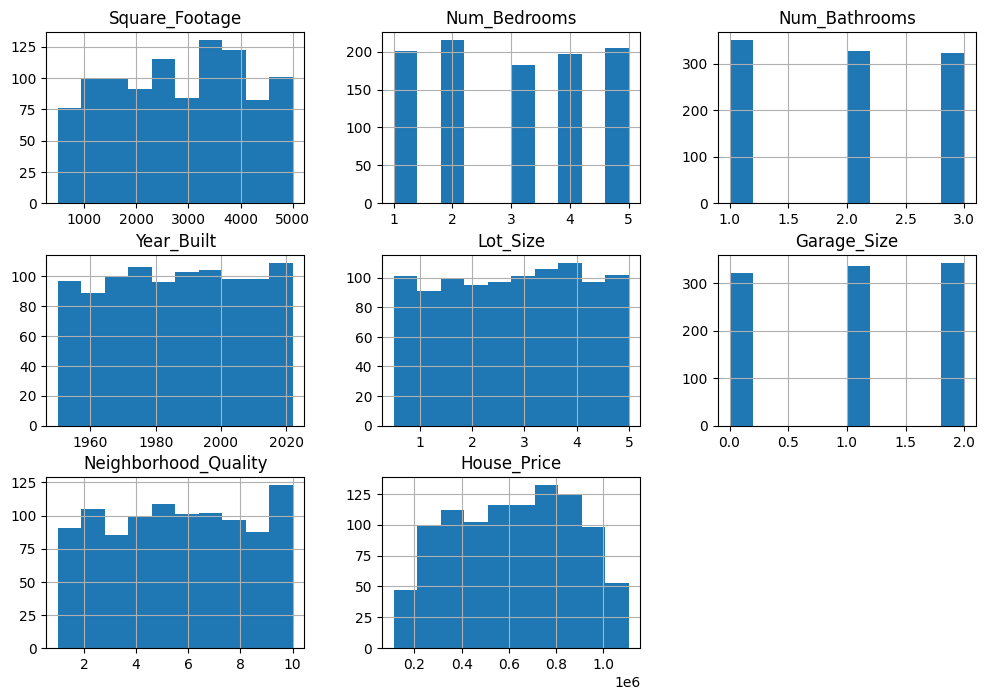

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

In [41]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

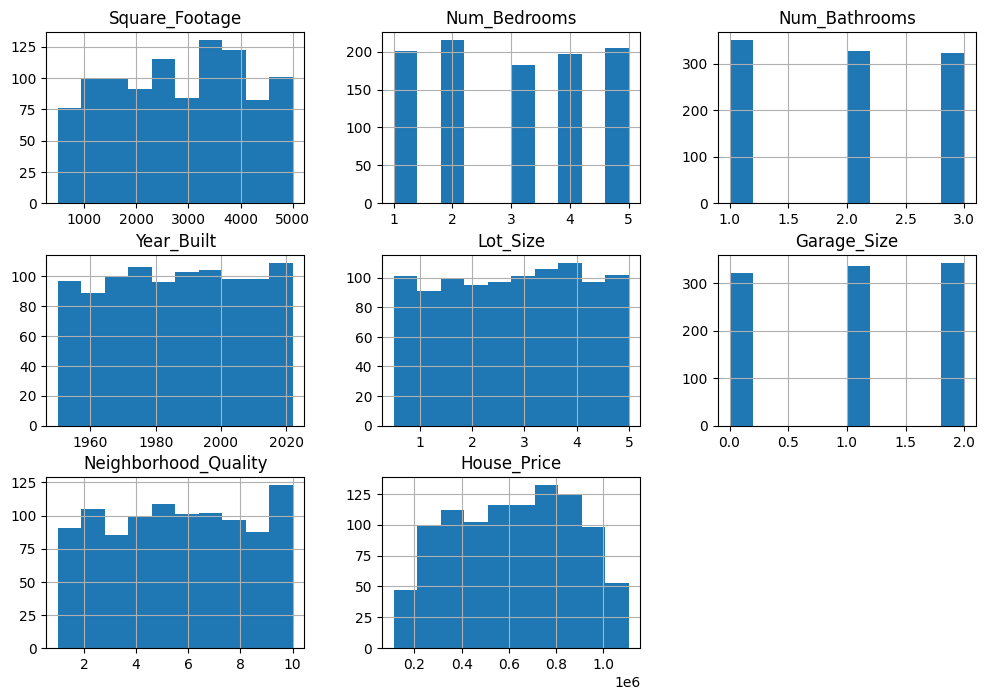

In [42]:
df.hist(figsize=(12,8))
plt.show()

#### Relationship with Target Variable

Here, we visualize the relationship between key features and the target variable ('House_Price') using scatter plots.

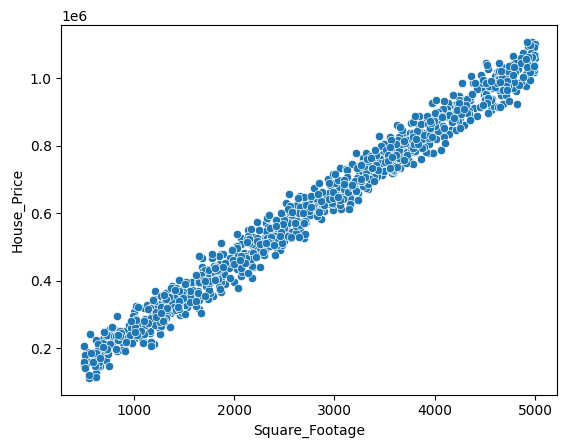

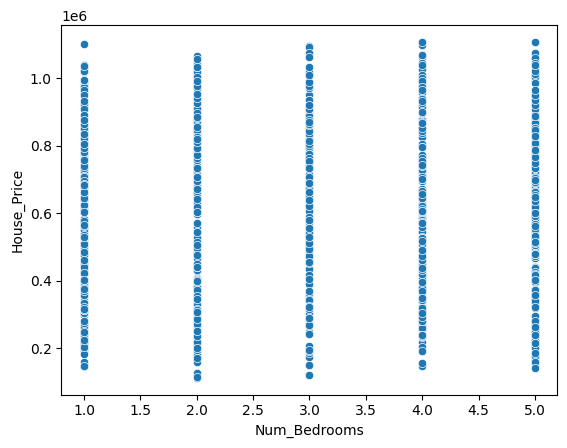

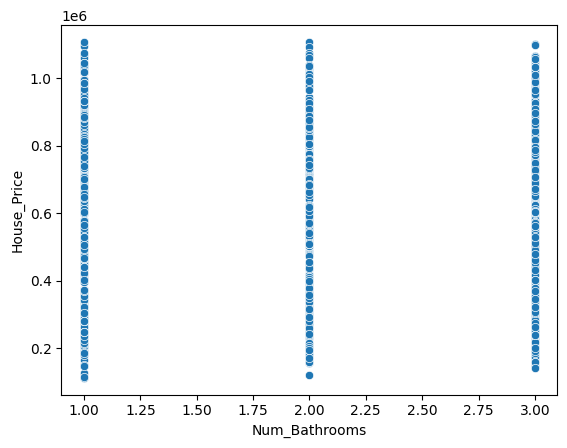

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.show()

sns.scatterplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.show()

sns.scatterplot(x='Num_Bathrooms', y='House_Price', data=df)
plt.show()

#### Correlation Heatmap

This heatmap displays the correlation matrix between all numerical features, helping to identify highly correlated variables.

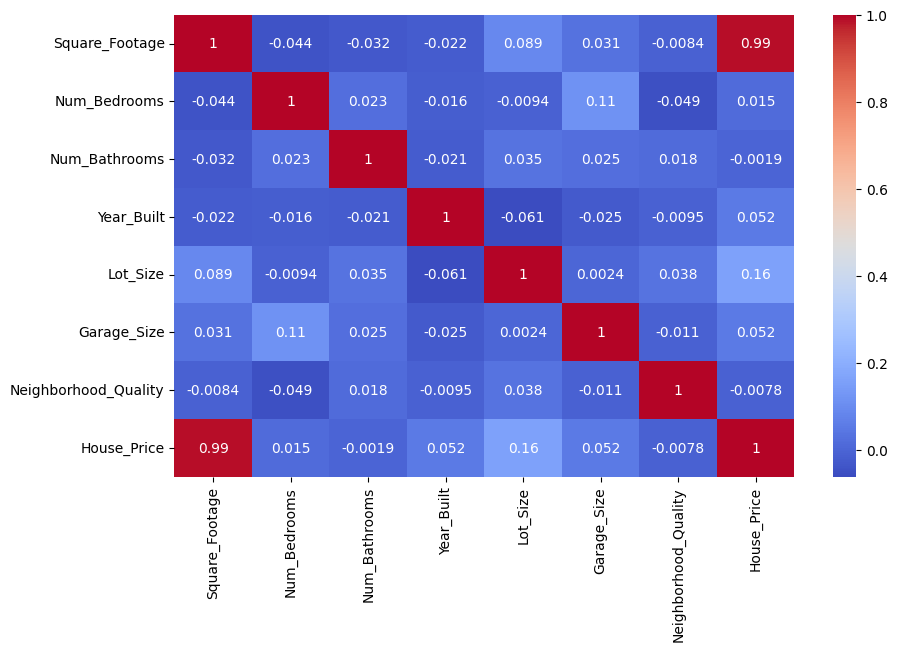

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### 5. Feature Engineering and Transformation

In this phase, we rename columns for better readability, check for skewness in the data, apply transformations like log transformation to normalize skewed features, and handle outliers using the Z-score method.

In [45]:
df.rename(columns={
    'Square_Footage': 'area',
    'Num_Bedrooms': 'bedrooms',
    'Num_Bathrooms': 'bathrooms',
    'Year_Built': 'year',
    'Lot_Size': 'lot',
    'Garage_Size': 'garage',
    'Neighborhood_Quality': 'quality',
    'House_Price': 'price'
}, inplace=True)

In [46]:
df.skew(numeric_only=True)

,0
area,-0.066001
bedrooms,0.025884
bathrooms,0.049917
year,-0.021254
lot,-0.044288
garage,-0.040400
quality,-0.020445
price,-0.063955


In [47]:
import numpy as np

df['price'] = np.log(df['price'])

In [48]:
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df))
df = df[(z < 3).all(axis=1)]

### 6. Data Splitting

This step separates the features (X) from the target variable (y) and then splits the dataset into training and testing sets to prepare for model building.

In [49]:
X = df.drop('price', axis=1)
y = df['price']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 7. Feature Scaling

Features are scaled using `StandardScaler` to normalize their ranges, which is crucial for many machine learning algorithms to perform optimally. After scaling, we check for any NaN values in the scaled data.

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
X_train.shape, X_test.shape

((796, 7), (200, 7))

In [53]:
y_train.shape, y_test.shape

((796,), (200,))

In [54]:
import numpy as np
np.isnan(X_train).sum()

np.int64(0)

### 8. Model Training

In this section, two regression models, Linear Regression and K-Nearest Neighbors (KNN) Regressor, are initialized and trained using the scaled training data.

In [55]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [56]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

### 9. Model Prediction and Evaluation

After training, both models predict house prices on the test set. A custom `evaluate` function is used to calculate and print key regression metrics (MAE, MSE, RMSE, MAPE, R2) for each model.

In [57]:
y_pred_lr = lr.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2:", r2)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_knn, "KNN Regression")


Linear Regression
MAE: 0.08696886464352614
MSE: 0.01143321394158345
RMSE: 0.10692620792669798
MAPE: 0.6638248317566935
R2: 0.9475148458007387

KNN Regression
MAE: 0.12876092494459723
MSE: 0.03149259567449076
RMSE: 0.1774615329430318
MAPE: 0.9927866882993933
R2: 0.8554305247364489


#### Adjusted R2 Score

Here, the adjusted R-squared score is calculated for both models, providing a more robust measure of model fit by accounting for the number of predictors.

In [59]:
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

n = X_test.shape[0]
p = X_test.shape[1]

r2_lr = r2_score(y_test, y_pred_lr)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nAdjusted R2 (Linear):", adjusted_r2(r2_lr, n, p))
print("Adjusted R2 (KNN):", adjusted_r2(r2_knn, n, p))


Adjusted R2 (Linear): 0.9456013245538907
Adjusted R2 (KNN): 0.8501597626174653


In [60]:
lr

LinearRegression()

### 10. Model and Scaler Saving

The trained Linear Regression model and the `StandardScaler` object are saved to disk using `pickle`. This allows for later reuse of the trained model and scaler without needing to retrain or refit them.

In [61]:
import pickle

pickle.dump(lr, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [62]:
import os
os.listdir()

['.config',
 'model.pkl',
 'house_price_regression_dataset.csv',
 'Machine Learning Task1_new (1).pdf',
 'scaler.pkl',
 'sample_data']